### Importing the neccesary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1.Extracting the data (reading data  from the csv file)

In [2]:
df=pd.read_csv(r"C:\Users\44755\Desktop\car insurance claim prediction\data.csv")

## 2.Exploratory data analysis

### shape of the data frame

In [44]:
df.shape

(58592, 39)

### To display all the columns

In [4]:
pd.set_option('display.max_columns', None)

### Top 5 rows of the data frame

In [5]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


### All the columns of the dataframe

In [6]:
df.columns

Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='object')

### Dropping the unneccesary columns that are not important for the model

In [7]:
df.drop(['policy_id','is_central_locking','is_power_door_locks','airbags'],axis=1,inplace=True)

### Data type of each column

In [8]:
df.dtypes

policy_tenure                       float64
age_of_car                          float64
age_of_policyholder                 float64
area_cluster                         object
population_density                    int64
make                                  int64
segment                              object
model                                object
fuel_type                            object
max_torque                           object
max_power                            object
engine_type                          object
is_esc                               object
is_adjustable_steering               object
is_tpms                              object
is_parking_sensors                   object
is_parking_camera                    object
rear_brakes_type                     object
displacement                          int64
cylinder                              int64
transmission_type                    object
gear_box                              int64
steering_type                   

### Count of non-null values and data type of each column

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 40 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_tenure                     58592 non-null  float64
 1   age_of_car                        58592 non-null  float64
 2   age_of_policyholder               58592 non-null  float64
 3   area_cluster                      58592 non-null  object 
 4   population_density                58592 non-null  int64  
 5   make                              58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  is_e

### Statistical summarie of all the numerical columns

In [10]:
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


### No of distinct values in each column

In [11]:
df.nunique()

policy_tenure                       58592
age_of_car                             49
age_of_policyholder                    75
area_cluster                           22
population_density                     22
make                                    5
segment                                 6
model                                  11
fuel_type                               3
max_torque                              9
max_power                               9
engine_type                            11
is_esc                                  2
is_adjustable_steering                  2
is_tpms                                 2
is_parking_sensors                      2
is_parking_camera                       2
rear_brakes_type                        2
displacement                            9
cylinder                                2
transmission_type                       2
gear_box                                2
steering_type                           3
turning_radius                    

### Dropping policy_tenure column which is not usefull

In [12]:
df.drop('policy_tenure',axis=1,inplace=True)

### Selecting columns that have object data type

In [13]:
obj_df=df.select_dtypes(include=['object'])

In [14]:
obj_df.head()
obj_columns=obj_df.columns

### Distinct values count in each categorical column

In [15]:
for i in df.select_dtypes('object'):
    print(df[i].value_counts())
    print('-'*30)
    

C8     13654
C2      7342
C5      6979
C3      6101
C14     3660
C13     3423
C10     3155
C9      2734
C7      2167
C12     1589
C1      1468
C11     1212
C19      952
C6       890
C15      771
C4       665
C17      492
C16      401
C21      379
C18      242
C22      207
C20      109
Name: area_cluster, dtype: int64
------------------------------
B2         18314
A          17321
C2         14018
B1          4173
C1          3557
Utility     1209
Name: segment, dtype: int64
------------------------------
M1     14948
M4     14018
M6     13776
M8      4173
M7      2940
M3      2373
M9      2114
M5      1598
M10     1209
M2      1080
M11      363
Name: model, dtype: int64
------------------------------
Petrol    20532
CNG       20330
Diesel    17730
Name: fuel_type, dtype: int64
------------------------------
113Nm@4400rpm     17796
60Nm@3500rpm      14948
250Nm@2750rpm     14018
82.1Nm@3400rpm     4173
91Nm@4250rpm       2373
200Nm@1750rpm      2114
200Nm@3000rpm      1598
85Nm@3000rpm

### Null values in each column

In [16]:
df.isnull().sum()

age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length                              0
width                               0
height                              0
gross_weight

## 3.Data visualization

### Heatmap of all the numerical columns

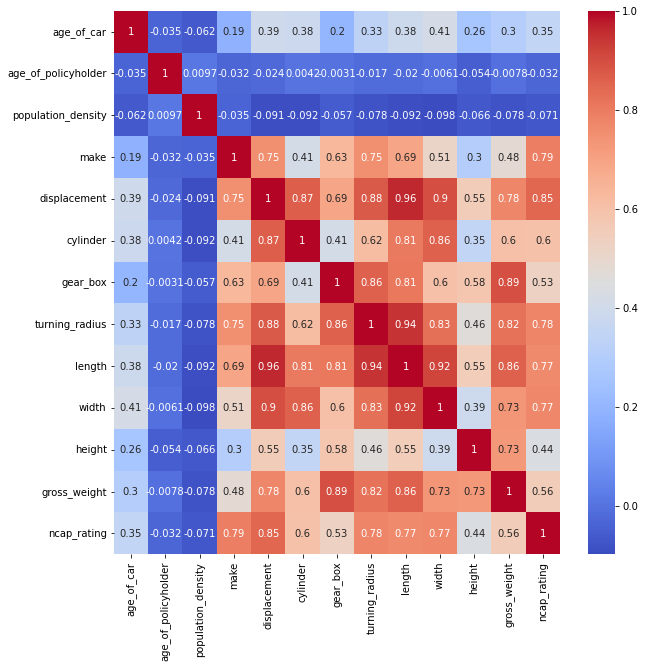

In [17]:
numeric_df=df.select_dtypes(include=['integer','float'])
numeric_df.drop('is_claim',inplace=True,axis=1)
corr=numeric_df.corr() 
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

### Displaying all the numerical columns

In [18]:
numeric_df=df.select_dtypes(include=['integer','float'])
numeric_df.drop('is_claim',inplace=True,axis=1)
for i in numeric_df.columns:
    print(i)

age_of_car
age_of_policyholder
population_density
make
displacement
cylinder
gear_box
turning_radius
length
width
height
gross_weight
ncap_rating


### Boxplot of numerical columns to find outliers

C:\Users\44755\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='age_of_car'>

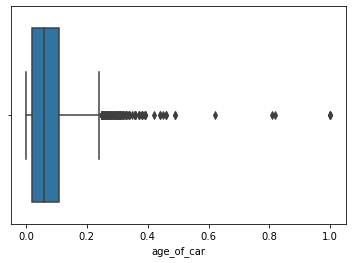

In [19]:
sns.boxplot(numeric_df['age_of_car'])

C:\Users\44755\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='width'>

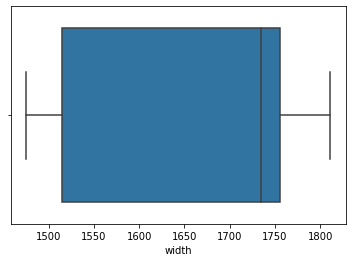

In [20]:
sns.boxplot(numeric_df['width'])

C:\Users\44755\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='length'>

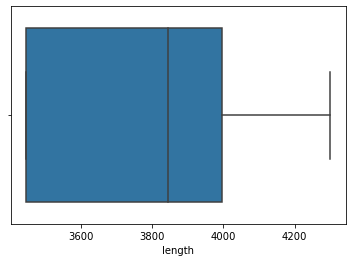

In [21]:
sns.boxplot(numeric_df['length'])

C:\Users\44755\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='height'>

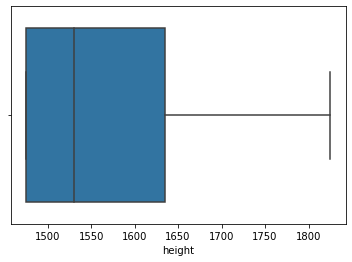

In [22]:
sns.boxplot(numeric_df['height'])

C:\Users\44755\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='age_of_policyholder'>

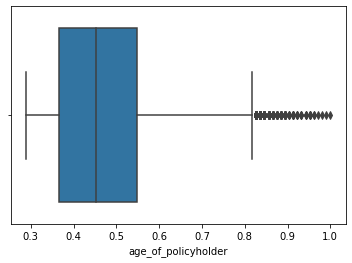

In [23]:
sns.boxplot(numeric_df['age_of_policyholder'])

   ##            4.Data Preprocessing

### Distinct value count of the target column

In [24]:
df['is_claim'].value_counts()

0    54844
1     3748
Name: is_claim, dtype: int64

### Converting categorical values to numerical values

In [25]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in obj_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder




In [26]:
df.head(3)

,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,0.05,0.644231,0,4990,1,0,0,0,5,2,6,0,0,0,1,0,1,796,3,1,5,2,4.6,3445,1515,1475,1185,0,0,0,0,0,1,0,0,0,1,0,0
1,0.02,0.375000,11,27003,1,0,0,0,5,2,6,0,0,0,1,0,1,796,3,1,5,2,4.6,3445,1515,1475,1185,0,0,0,0,0,1,0,0,0,1,0,0
2,0.02,0.384615,15,4076,1,0,0,0,5,2,6,0,0,0,1,0,1,796,3,1,5,2,4.6,3445,1515,1475,1185,0,0,0,0,0,1,0,0,0,1,0,0


### splitting the features and target

In [27]:
x = df.drop('is_claim',axis=1)
y = df["is_claim"]

### split training and test data

In [28]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Up sampling of the imbalanced target feature 

In [29]:
smote = SMOTE(random_state=42)

In [30]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

### Balanced target feature

In [31]:
y_train_smote.value_counts()

0    43881
1    43881
Name: is_claim, dtype: int64

### Dictionary of models

In [32]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

### Dictionary to store the cross validation results

In [39]:
cv_scores = {}

### Performing 5-fold cross validation for each model

In [33]:
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.92
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.89
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.92
----------------------------------------------------------------------


In [34]:
cv_scores

{'Decision Tree': array([0.83096907, 0.94639093, 0.94308341, 0.9474134 , 0.94832498]),
 'Random Forest': array([0.81786589, 0.91067054, 0.91220374, 0.91043756, 0.9088423 ]),
 'XGBoost': array([0.8034524 , 0.94661881, 0.93767092, 0.94644485, 0.94342525])}

### Training the decision tree classifier

In [35]:
model = DecisionTreeClassifier(random_state=42)

In [36]:
model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

### Evaluating the model on the test data

In [37]:
y_test_pred = model.predict(X_test)

Accuracy Score:
 0.8827545012373069
Confsuion Matrix:
 [[10289   674]
 [  700    56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94     10963
           1       0.08      0.07      0.08       756

    accuracy                           0.88     11719
   macro avg       0.51      0.51      0.51     11719
weighted avg       0.88      0.88      0.88     11719



### Accuracy Score , Confusion  Matrix , Classification Report of the model

In [43]:
print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print(' '*10)
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print(' '*10)
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.8827545012373069
          
Confsuion Matrix:
 [[10289   674]
 [  700    56]]
          
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94     10963
           1       0.08      0.07      0.08       756

    accuracy                           0.88     11719
   macro avg       0.51      0.51      0.51     11719
weighted avg       0.88      0.88      0.88     11719

